In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv("/content/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


### **Observations:**
- No missing values in the data
- Except **quality** column, remaining all are real numerical data columns.
- **Quality** column is discrete numerical.
- Id column can be ignored.

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.duplicated().sum()

np.int64(0)

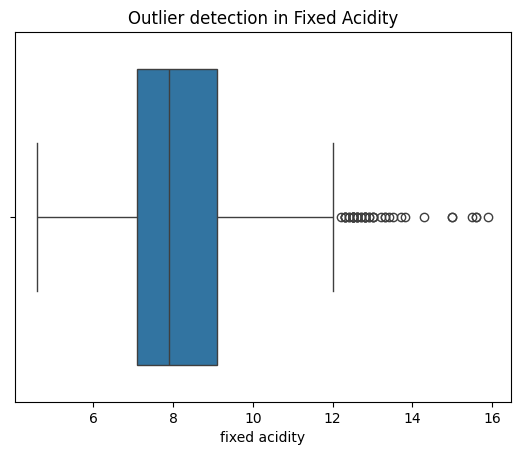

In [ ]:
# Fixed Acidity
sns.boxplot(df, x="fixed acidity")
plt.title("Outlier detection in Fixed Acidity")
plt.show()

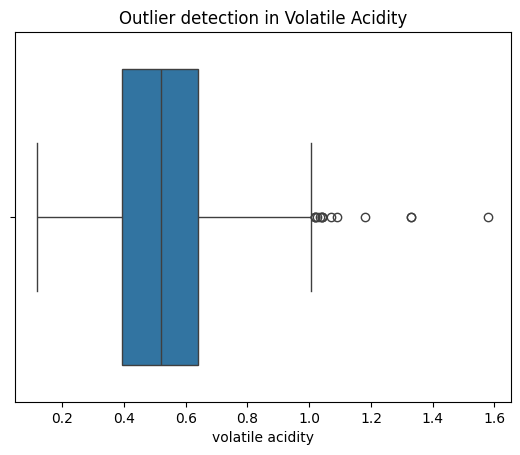

In [ ]:
# Volatile acidity
sns.boxplot(df, x="volatile acidity")
plt.title("Outlier detection in Volatile Acidity")
plt.show()

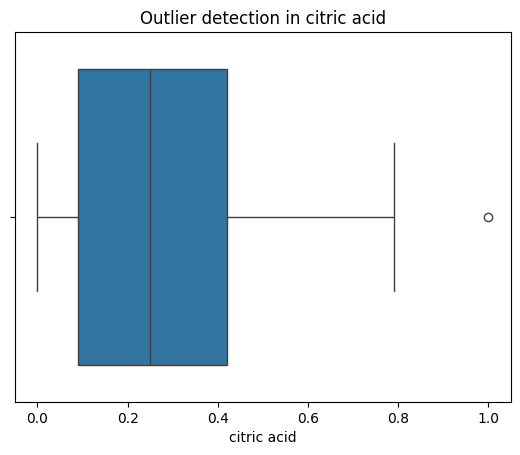

In [ ]:
# citric acid
sns.boxplot(df, x="citric acid")
plt.title("Outlier detection in citric acid")
plt.show()

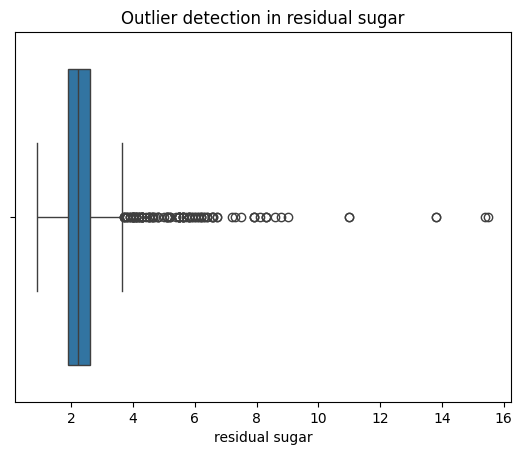

In [ ]:
# residual sugar
sns.boxplot(df, x="residual sugar")
plt.title("Outlier detection in residual sugar")
plt.show()

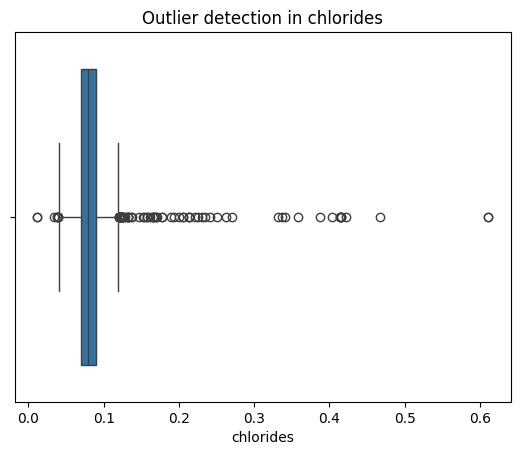

In [ ]:
# chlorides
sns.boxplot(df, x="chlorides")
plt.title("Outlier detection in chlorides")
plt.show()

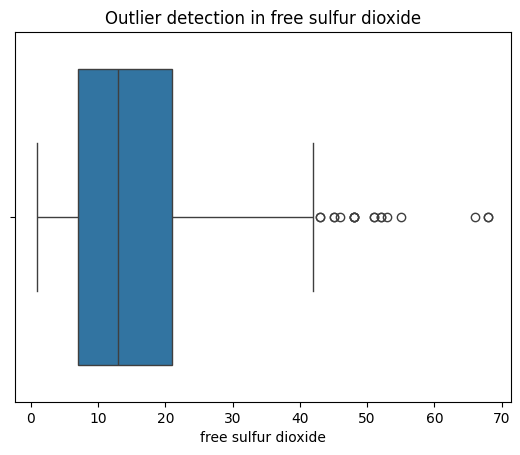

In [ ]:
# free sulfur dioxide
sns.boxplot(df, x="free sulfur dioxide")
plt.title("Outlier detection in free sulfur dioxide")
plt.show()

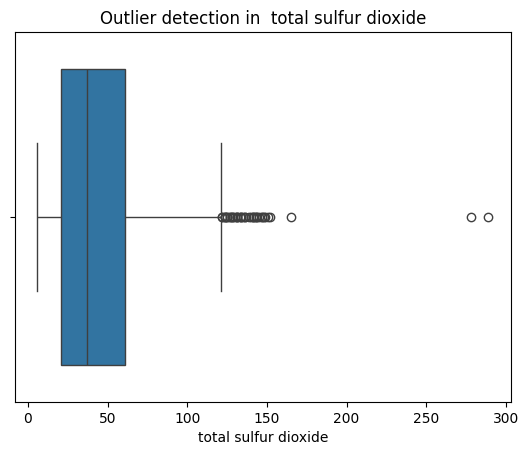

In [ ]:
# total sulfur dioxide
sns.boxplot(df, x="total sulfur dioxide")
plt.title("Outlier detection in  total sulfur dioxide")
plt.show()

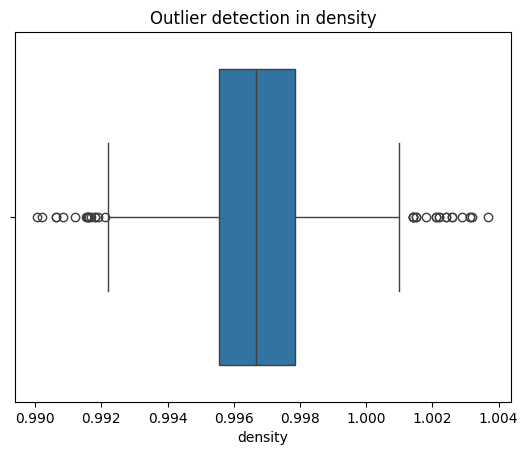

In [ ]:
# density
sns.boxplot(df, x="density")
plt.title("Outlier detection in density")
plt.show()

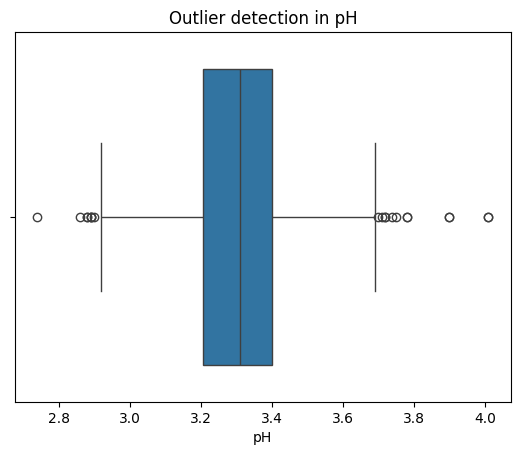

In [ ]:
# pH
sns.boxplot(df, x="pH")
plt.title("Outlier detection in pH")
plt.show()

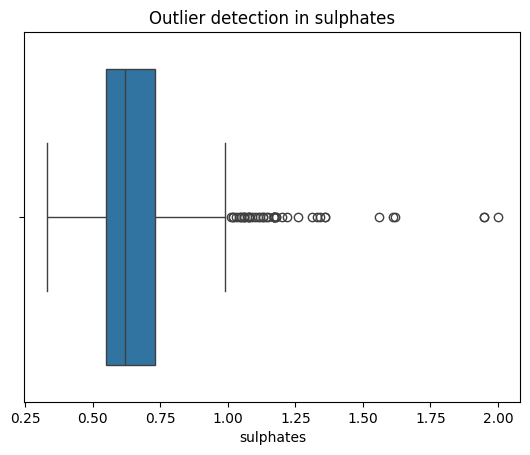

In [ ]:
# sulphates
sns.boxplot(df, x="sulphates")
plt.title("Outlier detection in sulphates")
plt.show()

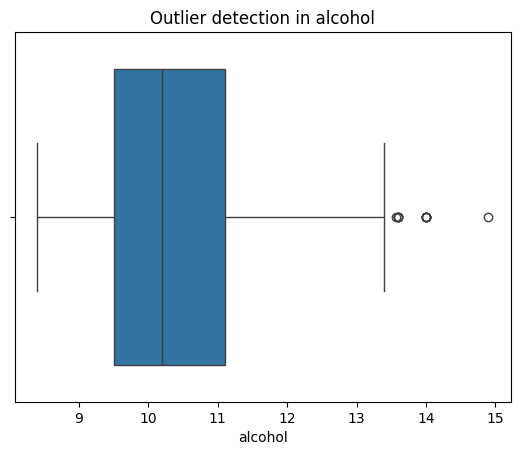

In [ ]:
# alcohol
sns.boxplot(df, x="alcohol")
plt.title("Outlier detection in alcohol")
plt.show()

### Observations:
- Except citric acid and alcohol, all the remaining columns have outliers.

## **Problem Statement:**
- Create a predictive model to get the quality of wine.

### Obseravations:
- **quality** is the target variable (Dependent Variable or Output Variable).

- As the target variable is available, it is a **Supervised Machine Learning Model**.
- It can be a regression or a classification.

- The data type of **quality** column is **discrete numerical**. Hence, it is a **Classification Model**.

In [ ]:
# Select the target variable
y=df["quality"]
y.shape

(1143,)

In [ ]:
# select input variable
X=df.drop(columns=["quality", "Id"])
X.shape

(1143, 11)

#### 2. Splitting Data into Train Data and Test Data

In [ ]:
# Import train test split from sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
## Let verify the shape of the train and test datasets
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(914, 11)
(229, 11)
(914,)
(229,)


**Observation:**

- Data Preprocessing is required on **X_train** and **X_test**.

- **X_train** and **X_test** has only **real numerical data** columns.

Text(0.5, 1.0, 'Comparison of Fixed Acidity and Volatile Acidity')

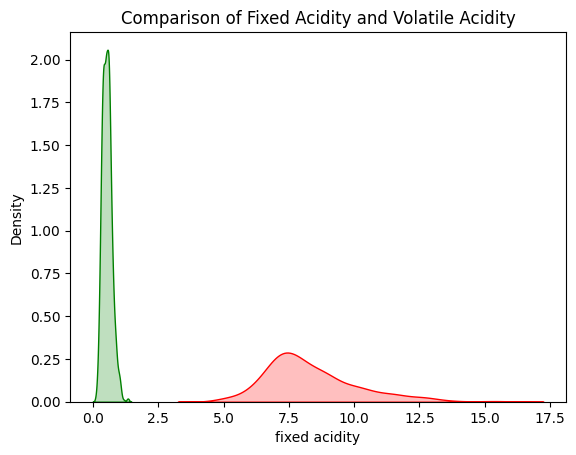

In [ ]:
"""Compare the data distribution of fixed acidity and volatile acidity before scaling"""

# We can use KDE plot to get the data distribution

sns.kdeplot(X_train, x="fixed acidity", color="red", fill=True)
sns.kdeplot(X_train, x="volatile acidity", color="green", fill=True)
plt.title("Comparison of Fixed Acidity and Volatile Acidity")

### **Numerical Data Preprocessing:**

- To bring the data into **same scale**.

    - Feature Scaling (Re-scaling)

- To change the **distribution of data** as per requirement.

    - Feature Transformation (Re-shaping)

### **1. Min-Max Scalar:**

- It brings the data in between 0 and 1.

- x_scaled = (x-min)/(max-min)

### **Rescaling Methods:**

- Min - Max Scaling (**Normalization**)

- Z - Transform Scaling (**Standardization**)

- **Robust** Scaling

In [ ]:
# we use sklearn library to apply scaling
from sklearn.preprocessing import MinMaxScaler
norm=MinMaxScaler()
# transform X_train
X_train_trans=norm.fit_transform(X_train)
# transform X_test
X_test_trans=norm.transform(X_test)

In [ ]:
# Let us print X_train_trans
# The output of minmax scaler is a numpy array
X_train_trans=pd.DataFrame(X_train_trans,columns=X_train.columns)
X_train_trans.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.592920,0.181818,0.45,0.075862,0.116861,0.074627,0.028369,0.640969,0.157480,0.197605,0.123077
1,0.238938,0.256198,0.24,0.110345,0.110184,0.388060,0.212766,0.470631,0.677165,0.155689,0.415385
2,0.212389,0.380165,0.28,0.268966,0.121870,0.164179,0.219858,0.459618,0.456693,0.221557,0.400000
3,0.088496,0.409091,0.00,0.048276,0.128548,0.223881,0.184397,0.310573,0.661417,0.113772,0.230769
4,0.380531,0.190083,0.40,0.186207,0.163606,0.164179,0.060284,0.397944,0.385827,0.221557,0.553846


In [ ]:
# Let us print X_test_trans
# The output of minmax scaler is a numpy array
X_test_trans=pd.DataFrame(X_test_trans,columns=X_test.columns)
X_test_trans.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.451327,0.247934,0.46,0.082759,0.103506,0.059701,0.031915,0.471366,0.417323,0.245509,0.600000
1,0.318584,0.066116,0.43,0.110345,0.106845,0.447761,0.156028,0.488253,0.622047,0.287425,0.307692
2,0.318584,0.132231,0.60,0.144828,0.153589,0.134328,0.053191,0.602790,0.511811,0.209581,0.338462
3,0.389381,0.272727,0.49,0.117241,0.120200,0.298507,0.241135,0.633627,0.480315,0.143713,0.200000
4,0.389381,0.446281,0.17,0.144828,0.108514,0.059701,0.021277,0.552863,0.433071,0.131737,0.307692


Text(0.5, 1.0, 'Comparison of Fixed Acidity and Volatile Acidity')

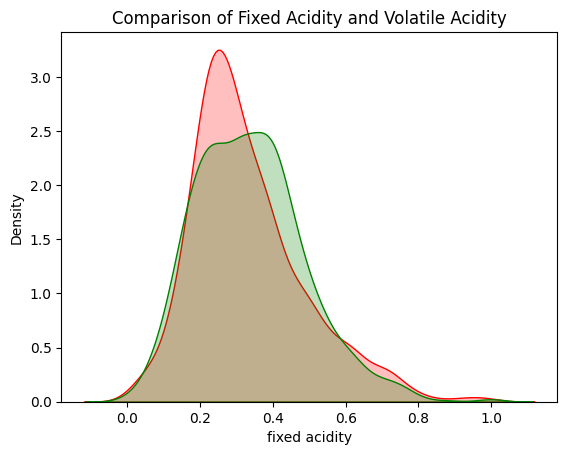

In [ ]:
# we can use KDE plot to get the data distribution
sns.kdeplot(X_train_trans,x="fixed acidity",color="red",fill=True)
sns.kdeplot(X_train_trans,x="volatile acidity",color="green",fill=True)
plt.title("Comparison of Fixed Acidity and Volatile Acidity")


### **2. Z- Transform Scaler (Standardization):**

- It adjust the data such that,

    - mean=0, std=1

- x_scaled=(x-mean)/(std)

In [ ]:
# Let us apply z-transform scaler (standard scaler)
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
# Let us transform X_train and X_test
X_train_trans2=ss.fit_transform(X_train)
X_test_trans2=ss.transform(X_test)
# Let us convert transformed data into data frames.
X_train_trans2=pd.DataFrame(X_train_trans2,columns=X_train.columns)
X_test_trans2=pd.DataFrame(X_test_trans2,columns=X_test.columns)

In [ ]:
X_train_trans2.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,1.677665,-1.036173,0.905575,-0.383619,-0.111455,-0.940542,-0.949699,1.075822,-2.346959,0.003100,-1.146732
1,-0.588311,-0.538461,-0.167695,-0.003370,-0.190639,1.128069,0.641575,-0.131564,1.863914,-0.401686,0.625252
2,-0.758259,0.291058,0.036737,1.745778,-0.052067,-0.349510,0.702778,-0.209628,0.077483,0.234406,0.531990
3,-1.551350,0.484612,-1.394289,-0.687819,0.027117,0.044511,0.396764,-1.266090,1.736311,-0.806472,-0.493896
4,0.318079,-0.980872,0.650034,0.833179,0.442831,-0.349510,-0.674286,-0.646784,-0.496727,0.234406,1.464613


In [ ]:
X_test_trans2.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.771274,-0.593763,0.956683,-0.307569,-0.269822,-1.039047,-0.919097,-0.126360,-0.241523,0.465713,1.744399
1,-0.078466,-1.810391,0.803359,-0.003370,-0.230230,1.522090,0.151952,-0.006662,1.417306,0.870499,-0.027584
2,-0.078466,-1.367981,1.672196,0.376880,0.324055,-0.546521,-0.735489,0.805201,0.524090,0.118753,0.158940
3,0.374729,-0.427859,1.110007,0.072680,-0.071863,0.537037,0.886387,1.023779,0.268886,-0.517339,-0.680420
4,0.374729,0.733468,-0.525451,0.376880,-0.210434,-1.039047,-1.010902,0.451312,-0.113921,-0.632992,-0.027584


Text(0.5, 1.0, 'Comparison of Fixed Acidity and Volatile Acidity')

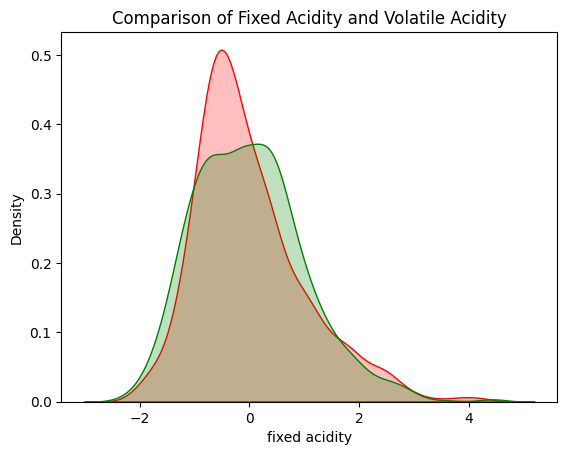

In [ ]:
# we can use KDE plot to get the data distribution
sns.kdeplot(X_train_trans2,x="fixed acidity",color="red",fill=True)
sns.kdeplot(X_train_trans2,x="volatile acidity",color="green",fill=True)
plt.title("Comparison of Fixed Acidity and Volatile Acidity")

### **3. Robust Scaler:**

- x_scale=(x-median)/(IQR)

In [ ]:
# Let us import robust scaler
from sklearn.preprocessing import RobustScaler
rs=RobustScaler()
# Transform X_train and X_test
X_train_trans3=rs.fit_transform(X_train)
X_test_trans3=rs.transform(X_test)

# Let us convert transfromed data into data frames.
X_train_trans3=pd.DataFrame(X_train_trans3,columns=X_train.columns)
X_test_trans3=pd.DataFrame(X_test_trans3,columns=X_test.columns)

In [ ]:
X_train_trans3.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,1.619048,-0.693878,0.580153,-0.285714,0.15,-0.500000,-0.539877,0.935412,-1.873418,0.222222,-0.5625
1,-0.285714,-0.326531,-0.061069,0.428571,-0.05,1.000000,0.736196,-0.097996,1.468354,-0.166667,0.6250
2,-0.428571,0.285714,0.061069,3.714286,0.30,-0.071429,0.785276,-0.164811,0.050633,0.444444,0.5625
3,-1.095238,0.428571,-0.793893,-0.857143,0.50,0.214286,0.539877,-1.069042,1.367089,-0.555556,-0.1250
4,0.476190,-0.653061,0.427481,2.000000,1.55,-0.071429,-0.319018,-0.538976,-0.405063,0.444444,1.1875


In [ ]:
X_test_trans3.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.857143,-0.367347,0.610687,-0.142857,-0.25,-0.571429,-0.515337,-0.093541,-0.202532,0.666667,1.3750
1,0.142857,-1.265306,0.519084,0.428571,-0.15,1.285714,0.343558,0.008909,1.113924,1.055556,0.1875
2,0.142857,-0.938776,1.038168,1.142857,1.25,-0.214286,-0.368098,0.703786,0.405063,0.333333,0.3125
3,0.523810,-0.244898,0.702290,0.571429,0.25,0.571429,0.932515,0.890869,0.202532,-0.277778,-0.2500
4,0.523810,0.612245,-0.274809,1.142857,-0.10,-0.571429,-0.588957,0.400891,-0.101266,-0.388889,0.1875


Text(0.5, 1.0, 'Comparison of Fixed Acidity and Volatile Acidity')

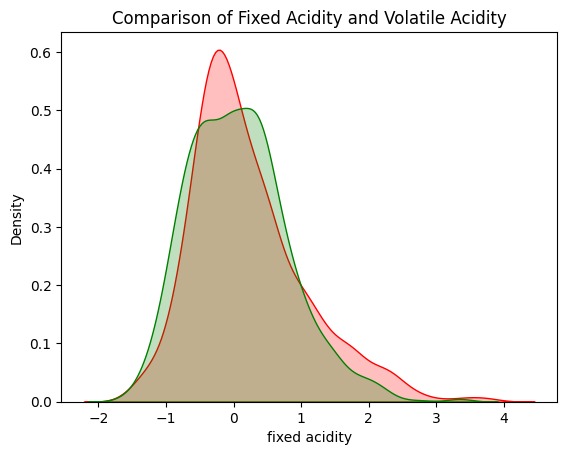

In [ ]:
# we can use KDE plot to get the data distribution
sns.kdeplot(X_train_trans3,x="fixed acidity",color="red",fill=True)
sns.kdeplot(X_train_trans3,x="volatile acidity",color="green",fill=True)
plt.title("Comparison of Fixed Acidity and Volatile Acidity")

### **Data Transformation Methods (Reshaping)**

- to convert **non normal distribution** into a **normal distribution**.

- various transformations are:

    - **log transformation** : if the data is **slightly right skewed**.
    - **box-cox transformation** : **Right skewed** with **long tail**.
    - **yeo-jhonson transformation** : **Left** and **right** skewed
    - **quantile transformation** : **any** data

In [ ]:
# Let us verify the data distribution of all the input columns
X_train.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

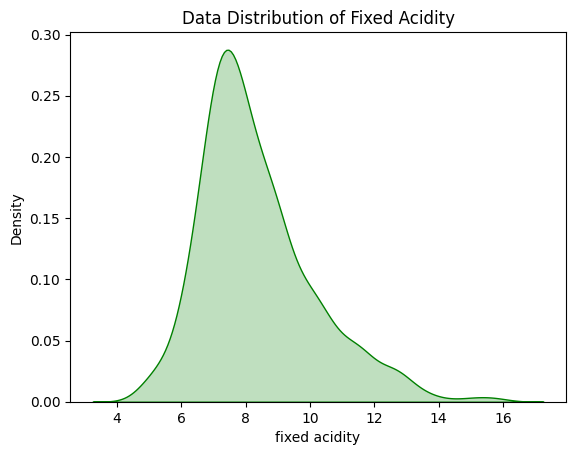

In [ ]:
# Data distribution of fixed acidity
# Data distribution is verified using KDE plot
sns.kdeplot(X_train,x="fixed acidity",color="green",fill=True)
plt.title("Data Distribution of Fixed Acidity")
plt.show()

Text(0.5, 1.0, 'Verification of Normal Distribution - Fixed Acidity')

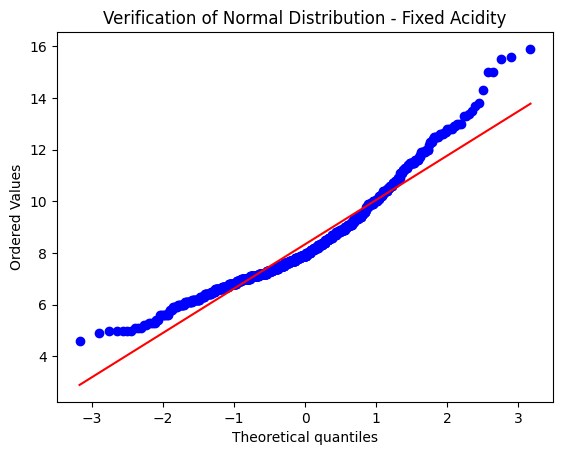

In [ ]:
# Let us create a QQ plot for fixed acidity column
stats.probplot(X_train["fixed acidity"],dist="norm",plot=plt)
plt.title("Verification of Normal Distribution - Fixed Acidity")

**Observation:**

- The fixed acidity column is not a normal distribution.

**Power_Trnaform:**

- box-cox
- yeo-jhonson

In [ ]:
# Let us apply box cox transformation
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method="yeo-johnson")
# Let us apply transformation to X_train
X_train_bc=pt.fit_transform(X_train)
# Let us transfrom X_test
X_test_bc=pt.transform(X_test)

In [ ]:
# The output is numpy array, we will convert numpy array into data frame
X_train_bc=pd.DataFrame(X_train_bc,columns=X_train.columns)
X_test_bc=pd.DataFrame(X_test_bc,columns=X_test.columns)

In [ ]:
X_train_bc.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,1.540764,-1.084595,0.935408,-0.362277,0.131659,-1.089896,-1.260757,1.074607,-2.470520,0.257446,-1.406616
1,-0.522367,-0.476311,-0.068060,0.463548,-0.060284,1.154874,0.875690,-0.117581,1.810061,-0.300304,0.806456
2,-0.753104,0.395261,0.140051,1.879572,0.267270,-0.110175,0.918094,-0.196092,0.101903,0.525388,0.728224
3,-2.083523,0.577179,-1.540853,-1.407744,0.437667,0.325639,0.692420,-1.276085,1.692738,-1.000545,-0.377578
4,0.487779,-1.013340,0.715103,1.408653,1.166082,-0.110175,-0.597621,-0.639019,-0.479094,0.525388,1.391193


In [ ]:
X_test_bc.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.887241,-0.540401,0.978240,-0.163668,-0.265812,-1.328346,-1.170456,-0.112350,-0.218839,0.762676,1.546822
1,0.085853,-2.195791,0.848536,0.463548,-0.161288,1.380953,0.482530,0.007671,1.396390,1.116133,0.187400
2,0.085853,-1.533510,1.539138,0.992501,0.983386,-0.378099,-0.721233,0.810968,0.542643,0.395532,0.382411
3,0.540940,-0.350565,1.104393,0.587751,0.222833,0.751055,1.038309,1.024067,0.291960,-0.484106,-0.639696
4,0.540940,0.800714,-0.455010,0.992501,-0.110354,-1.328346,-1.459899,0.463113,-0.089938,-0.680402,0.187400


<Axes: xlabel='fixed acidity', ylabel='Density'>

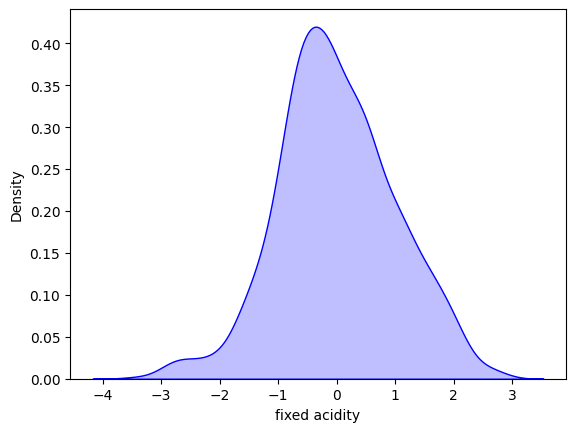

In [ ]:
# Let us verify the data distribution after applying transformation
sns.kdeplot(X_train_bc,x="fixed acidity",color="blue",fill=True)

((array([-3.17157283e+00, -2.90435131e+00, -2.75509777e+00, -2.64976531e+00,
         -2.56754733e+00, -2.49971313e+00, -2.44173921e+00, -2.39096813e+00,
         -2.34570127e+00, -2.30478474e+00, -2.26739769e+00, -2.23293467e+00,
         -2.20093588e+00, -2.17104364e+00, -2.14297403e+00, -2.11649778e+00,
         -2.09142699e+00, -2.06760571e+00, -2.04490297e+00, -2.02320773e+00,
         -2.00242497e+00, -1.98247274e+00, -1.96327984e+00, -1.94478403e+00,
         -1.92693054e+00, -1.90967092e+00, -1.89296212e+00, -1.87676567e+00,
         -1.86104708e+00, -1.84577530e+00, -1.83092225e+00, -1.81646247e+00,
         -1.80237281e+00, -1.78863213e+00, -1.77522108e+00, -1.76212192e+00,
         -1.74931832e+00, -1.73679523e+00, -1.72453874e+00, -1.71253597e+00,
         -1.70077496e+00, -1.68924461e+00, -1.67793457e+00, -1.66683518e+00,
         -1.65593742e+00, -1.64523284e+00, -1.63471353e+00, -1.62437207e+00,
         -1.61420146e+00, -1.60419514e+00, -1.59434691e+00, -1.58465093e+00,

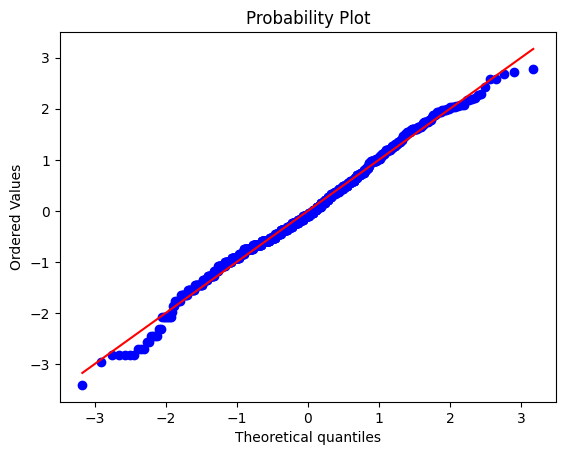

In [ ]:
# QQ plot for fixed acidity
stats.probplot(X_train_bc["fixed acidity"],dist="norm",plot=plt)

### **Qunatile Tranformation**

- **any** distribution -----> **normal** OR **uniform**

In [ ]:
# Quantile Transformer
from sklearn.preprocessing import QuantileTransformer
qt=QuantileTransformer(output_distribution='normal')
# Let us apply qunatile transformation on X_train
X_train_qt=qt.fit_transform(X_train)
X_test_qt=qt.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (914). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
# Let us convert output into data frame
X_train_qt=pd.DataFrame(X_train_qt,columns=X_train.columns)
X_test_qt=pd.DataFrame(X_test_qt,columns=X_test.columns)

In [ ]:
X_train_qt.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,1.424036,-1.036199,0.771675,-0.403274,0.224250,-0.933634,-1.164430,1.145706,-2.221946,0.305308,-1.615312
1,-0.495943,-0.421208,-0.111422,0.544670,-0.070067,1.064801,0.816840,-0.122480,1.871064,-0.268117,0.666755
2,-0.834211,0.328403,0.100379,1.595393,0.442304,-0.125246,0.853812,-0.208791,0.090725,0.519367,0.589819
3,-1.985423,0.559057,-5.199338,-1.504199,0.639568,0.270964,0.601293,-1.380024,1.719999,-1.074531,-0.228475
4,0.527238,-0.961593,0.565489,1.331838,1.335178,-0.125246,-0.516228,-0.731616,-0.486651,0.519367,1.321906


In [ ]:
X_test_qt.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.857772,-0.489743,0.814925,-0.154358,-0.421208,-1.308864,-1.059974,-0.118331,-0.253914,0.740615,1.462943
1,0.152969,-2.291997,0.689212,0.544670,-0.242588,1.305638,0.419708,0.016474,1.401691,1.072089,0.161308
2,0.152969,-1.543653,1.605273,1.099312,1.200331,-0.345840,-0.627822,0.912614,0.626151,0.419708,0.324060
3,0.580046,-0.338562,1.012995,0.697942,0.375138,0.683999,0.946446,1.086838,0.292389,-0.463599,-0.465128
4,0.580046,0.818758,-0.413719,1.099312,-0.158527,-1.308864,-1.454984,0.541489,-0.130782,-0.689212,0.161308


((array([-3.17157283e+00, -2.90435131e+00, -2.75509777e+00, -2.64976531e+00,
         -2.56754733e+00, -2.49971313e+00, -2.44173921e+00, -2.39096813e+00,
         -2.34570127e+00, -2.30478474e+00, -2.26739769e+00, -2.23293467e+00,
         -2.20093588e+00, -2.17104364e+00, -2.14297403e+00, -2.11649778e+00,
         -2.09142699e+00, -2.06760571e+00, -2.04490297e+00, -2.02320773e+00,
         -2.00242497e+00, -1.98247274e+00, -1.96327984e+00, -1.94478403e+00,
         -1.92693054e+00, -1.90967092e+00, -1.89296212e+00, -1.87676567e+00,
         -1.86104708e+00, -1.84577530e+00, -1.83092225e+00, -1.81646247e+00,
         -1.80237281e+00, -1.78863213e+00, -1.77522108e+00, -1.76212192e+00,
         -1.74931832e+00, -1.73679523e+00, -1.72453874e+00, -1.71253597e+00,
         -1.70077496e+00, -1.68924461e+00, -1.67793457e+00, -1.66683518e+00,
         -1.65593742e+00, -1.64523284e+00, -1.63471353e+00, -1.62437207e+00,
         -1.61420146e+00, -1.60419514e+00, -1.59434691e+00, -1.58465093e+00,

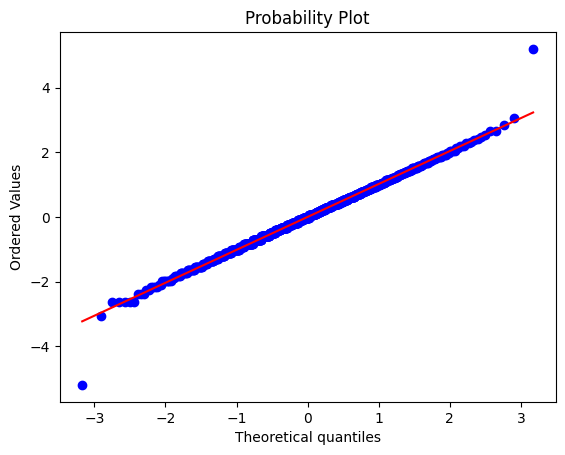

In [ ]:
# Let us verify the data distribution of fixed acidity column.
stats.probplot(X_train_qt["fixed acidity"],dist="norm",plot=plt)

Text(0.5, 1.0, 'DIstribution of Fixed Acidity')

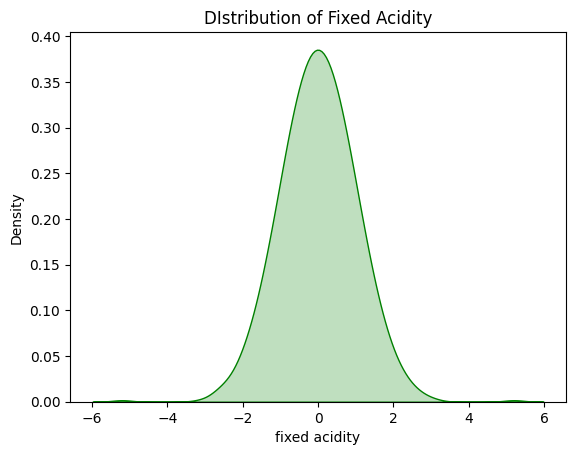

In [ ]:
# KDE plot
sns.kdeplot(X_train_qt,x="fixed acidity",color="green",fill=True)
plt.title("DIstribution of Fixed Acidity")